# 08_get_binding_pocket_properties

Notebook for extracting binding-pocket properties with or without an explicit ligand.


## Python Path Setup


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


## Imports


In [2]:
import importlib
import pandas as pd

import agentic_protein_design.steps.get_binding_pocket_properties as pocket_script
pocket_script = importlib.reload(pocket_script)

default_user_inputs = pocket_script.default_user_inputs
run_binding_pocket_property_extraction = pocket_script.run_binding_pocket_property_extraction


## Workflow Skeleton

1. Choose whether a ligand is present.
2. Run either `PocketAnalysis` or `LigandPocketAnalysis` from `tools/struct/`.
3. Inspect the generated binding-pocket property tables.


## User Inputs (Edit This Cell)


In [3]:
user_inputs = default_user_inputs()

# Data root key from project_config/variables.py (address_dict)
user_inputs["root_key"] = "examples"
user_inputs["data_subfolder"] = ""

# Set True to use LigandPocketAnalysis, False to use PocketAnalysis
user_inputs["ligand_present"] = True

# Shared analysis settings
user_inputs["protein_molname"] = "A"
user_inputs["plot_properties"] = False
user_inputs["struct_csv_subdirectory_name"] = "structure_csv"

# Ligand-aware settings (used when ligand_present = True)
user_inputs["ligand_molname"] = "D"
user_inputs["dist_thres"] = 6
user_inputs["analyse_binding_pocket_without_ligand"] = True
user_inputs["seq_align_fname"] = "UPO_peroxygenation_ali.fasta"
user_inputs["binding_pocket_residues_fname"] = "residues_near_ligand.csv"
user_inputs["struct_dict"] = {
    "ET096": "ET096_S82",
    "CviUPO": "CviUPO_S82",
    "DcaUPO": "DcaUPO_S82",
    "TE314": "TE314_S82",
    "OA167": "OA167_S82",
}

# Ligand-free settings (used when ligand_present = False)
# pocket_residues_source = "csv": load {root}/pdb/{data_subfolder}/binding_pocket_residues_fname
# pocket_residues_source = "inline": use pocket_residues_dict below
user_inputs["pocket_residues_source"] = "csv"
user_inputs["pocket_residues_dict"] = {
    # "ET096": [69, 73, 158],
    # "CviUPO": [69, 73, 158],
}

user_inputs


{'root_key': 'examples',
 'data_subfolder': '',
 'ligand_present': True,
 'protein_molname': 'A',
 'ligand_molname': 'D',
 'dist_thres': 6,
 'plot_properties': False,
 'analyse_binding_pocket_without_ligand': True,
 'seq_align_fname': 'UPO_peroxygenation_ali.fasta',
 'binding_pocket_residues_fname': 'residues_near_ligand.csv',
 'struct_csv_subdirectory_name': 'structure_csv',
 'pocket_residues_source': 'csv',
 'pocket_residues_dict': {},
 'struct_dict': {'ET096': 'ET096_S82',
  'CviUPO': 'CviUPO_S82',
  'DcaUPO': 'DcaUPO_S82',
  'TE314': 'TE314_S82',
  'OA167': 'OA167_S82'}}

## Run Binding Pocket Property Extraction


Ref Object: ET096_S82.pdb (243 residues) 

CviUPO_S82.pdb (226 residues)
TM-align score: None
RMSD (superposed residues): 0
RMSD (aligned residues): 1.12
# of aligned residues: 205/226 (90.7%)
[IDENTICAL] all: 68 (33.2%); hydrophobic: 24 (11.7%); non-hydrophobic: 44 (21.5%)
[SIMILAR] all: 126 (61.5%); hydrophobic: 60 (29.3%); non-hydrophobic: 66 (32.2%)

DcaUPO_S82.pdb (222 residues)
TM-align score: None
RMSD (superposed residues): 0.73
RMSD (aligned residues): 0.34
# of aligned residues: 216/222 (97.3%)
[IDENTICAL] all: 96 (44.4%); hydrophobic: 36 (16.7%); non-hydrophobic: 60 (27.8%)
[SIMILAR] all: 151 (69.9%); hydrophobic: 65 (30.1%); non-hydrophobic: 86 (39.8%)

TE314_S82.pdb (248 residues)
TM-align score: None
RMSD (superposed residues): 21.32
RMSD (aligned residues): 0.98
# of aligned residues: 199/248 (80.2%)
[IDENTICAL] all: 78 (39.2%); hydrophobic: 27 (13.6%); non-hydrophobic: 51 (25.6%)
[SIMILAR] all: 131 (65.8%); hydrophobic: 58 (29.1%); non-hydrophobic: 73 (36.7%)

OA167_S82

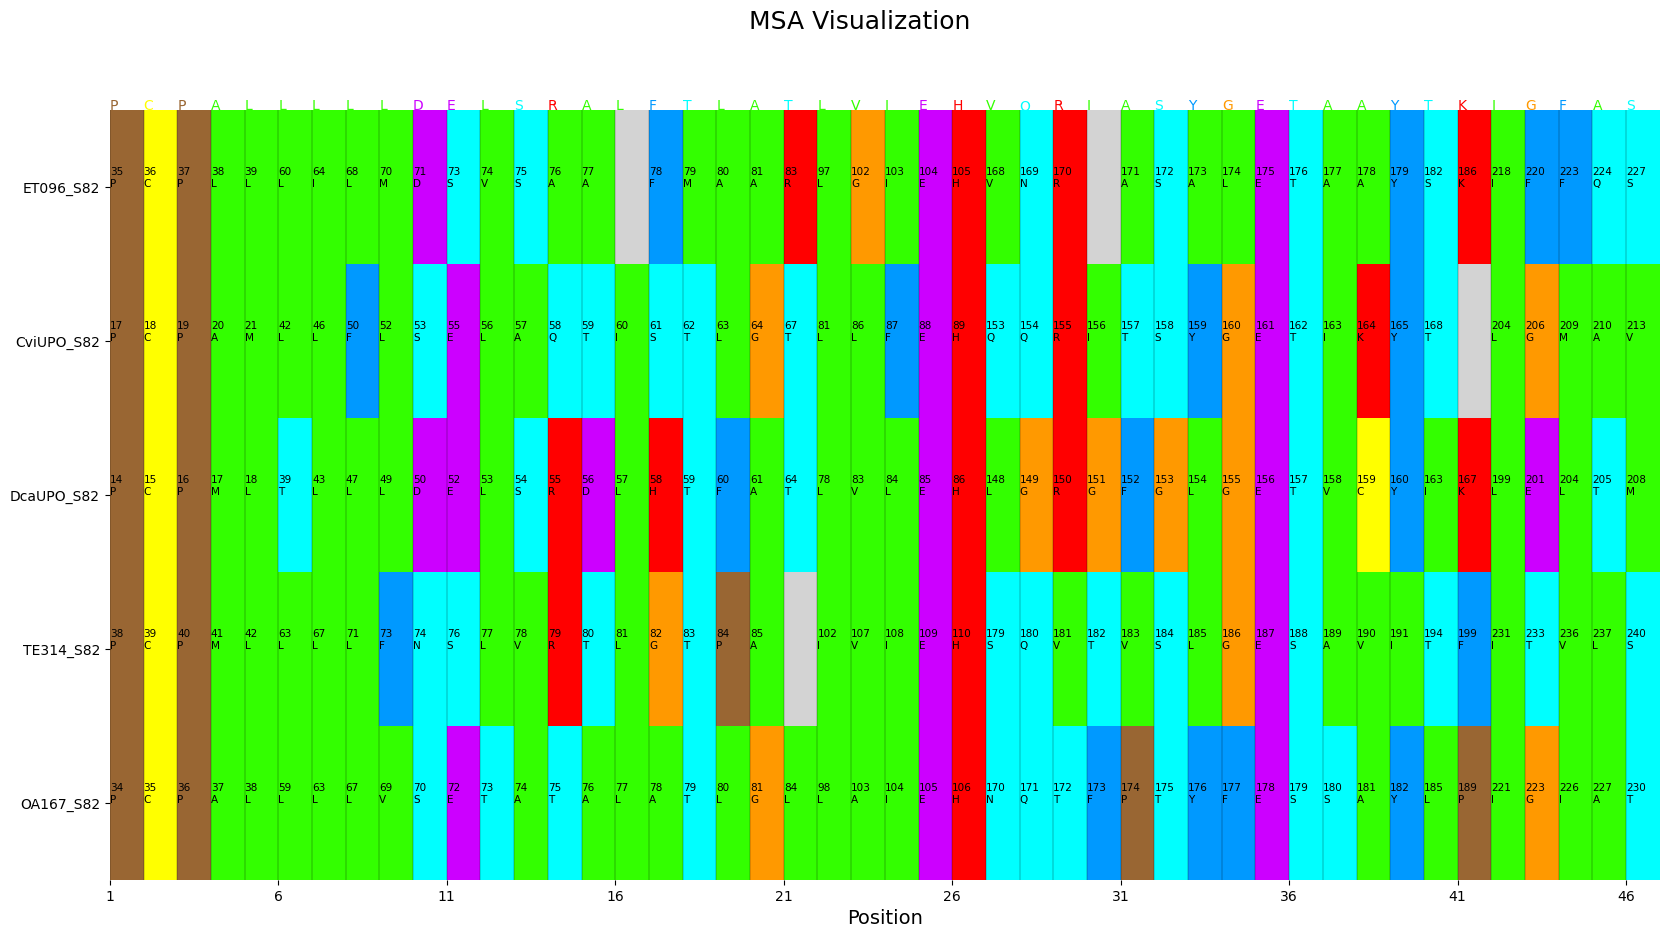

Parsed 1933 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/structure_csv/ET096_S82.csv
Parsed 1883 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/structure_csv/CviUPO_S82.csv
Parsed 1794 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/structure_csv/DcaUPO_S82.csv
Parsed 1855 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/structure_csv/TE314_S82.csv
Parsed 1947 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/structure_csv/OA167_S82.csv
[ET096_S82] Binding Pocket residues (38): [35, 36, 38, 60, 64, 70, 73, 74, 75, 76, 77, 78, 79, 80, 81, 83, 97, 102, 103, 104, 105, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 182, 218, 220, 223, 224, 227]
FE [-5.921  0.574 -3.06 ]
N [-10.585  -4.564  -1.581]
[CviUPO_S82] Binding Pocket residues (39): [18, 

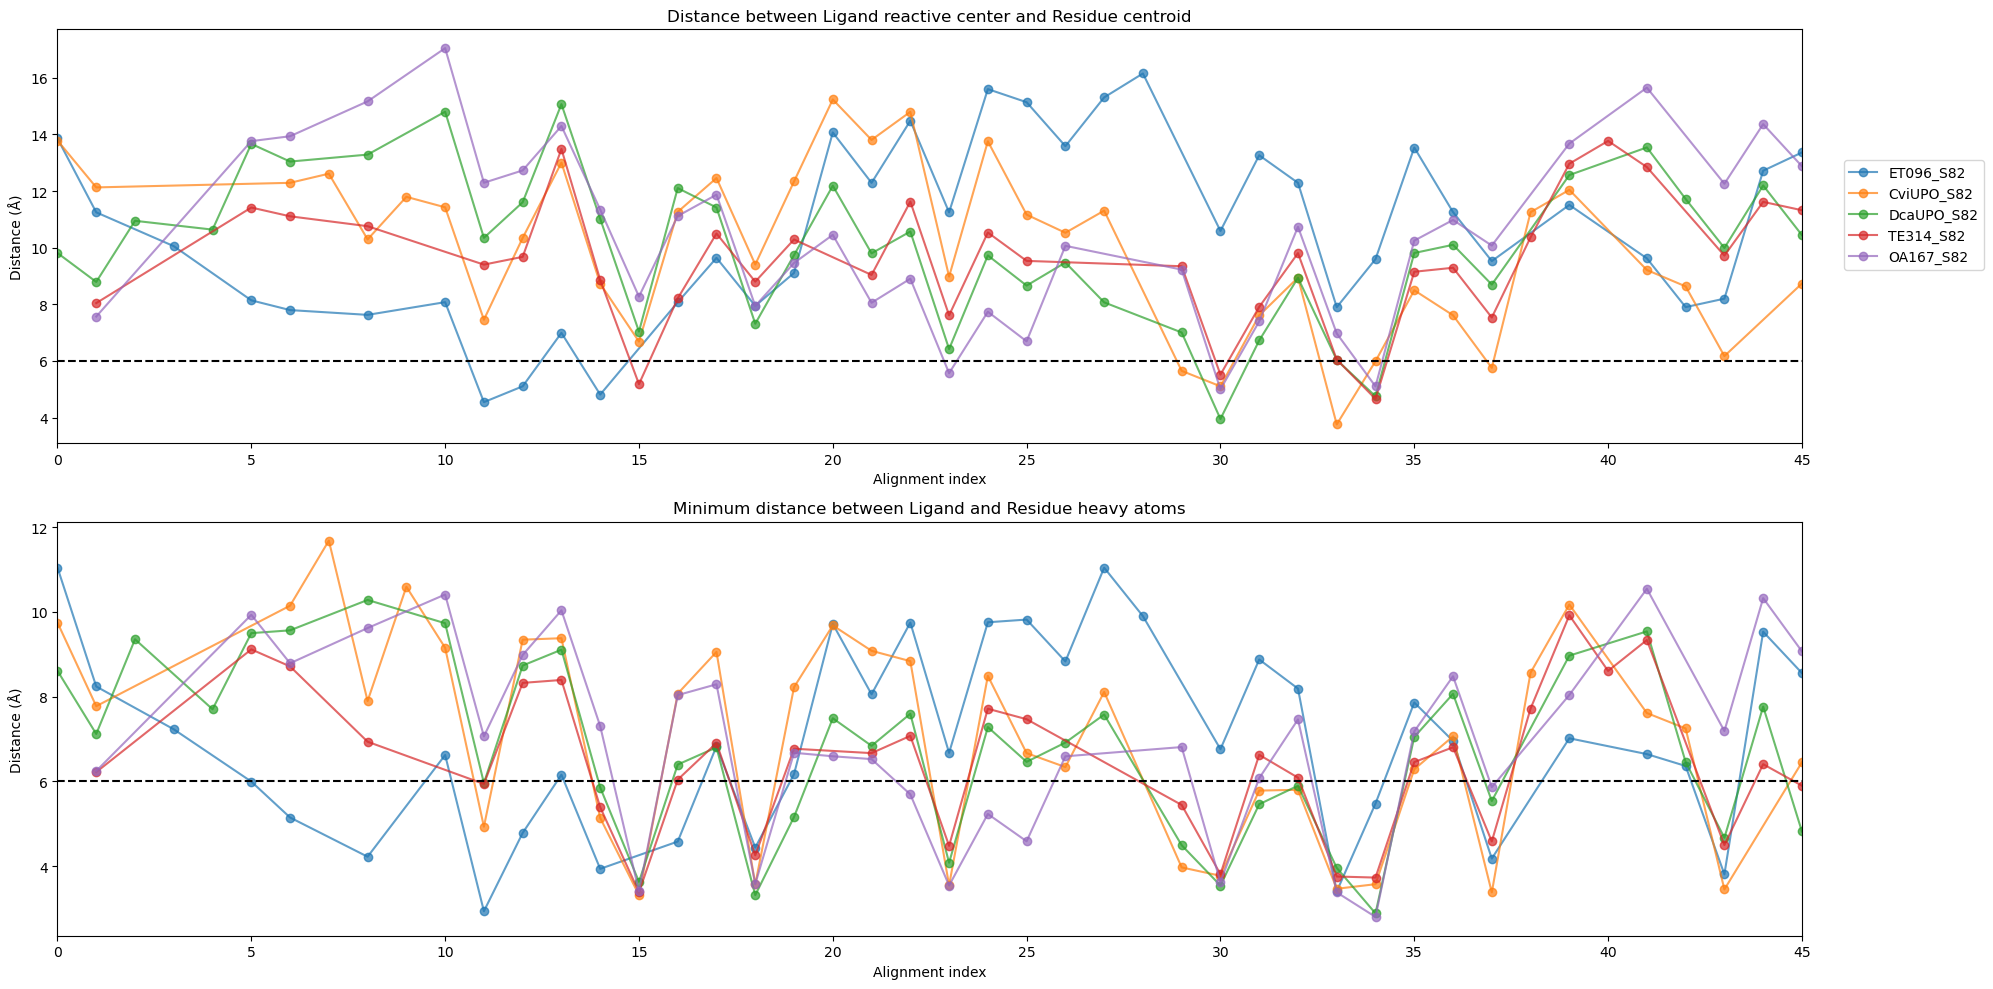

1 100 74V 57L 55L 77L 73T 2.937 4.931 5.96 5.94 7.062
2 103 77A 60T 58D 80T 76A 3.937 5.137 5.856 5.39 7.304
3 104 - 61I 59L 81L 77L nan 3.32 3.631 3.386 3.409
4 107 80A 64L 62F 84P 80L 4.438 3.57 3.317 4.257 3.579
5 138 103I 88F 86L 108I 104I 6.673 3.549 4.081 4.48 3.544
6 218 - 157I 153G 182T 173F nan 3.971 4.494 5.444 6.81
7 219 171A 158T 154F 183V 174P 6.76 3.773 3.543 3.81 3.623
8 220 172S 159S 155G 184S 175T 8.876 5.783 5.461 6.627 6.075
9 221 173A 160Y 156L 185L 176Y 8.189 5.802 5.897 6.088 7.461
10 222 174L 161G 157G 186G 177F 3.404 3.467 3.959 3.756 3.382
11 226 178A 165K 161C 190V 181A 4.179 3.381 5.538 4.584 5.863
12 278 223F 210M 206L 236V 226I 3.808 3.452 4.669 4.498 7.189
13 282 227S 214V 210M 240S 230T 8.556 6.451 4.819 5.899 9.068
Filtered alignment index (13): [99, 102, 103, 106, 137, 217, 218, 219, 220, 221, 225, 277, 281]
selected_residues: {'ET096_S82': [74, 77, 80, 103, 171, 172, 173, 174, 178, 223, 227], 'CviUPO_S82': [57, 60, 61, 64, 88, 157, 158, 159, 160, 161, 

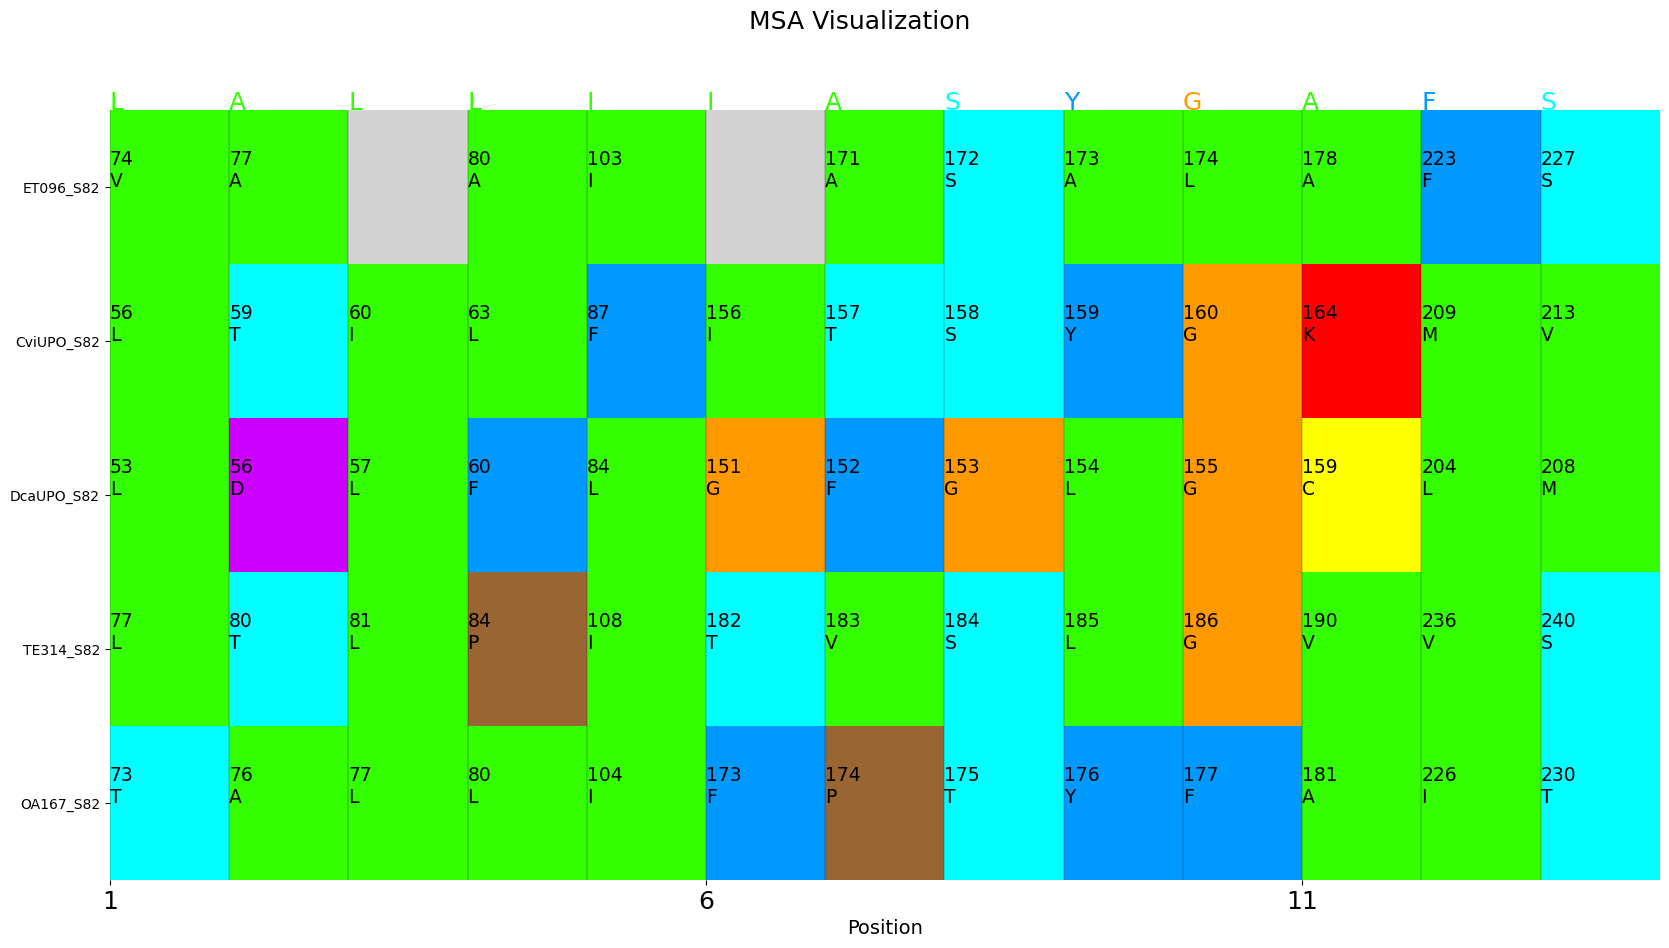

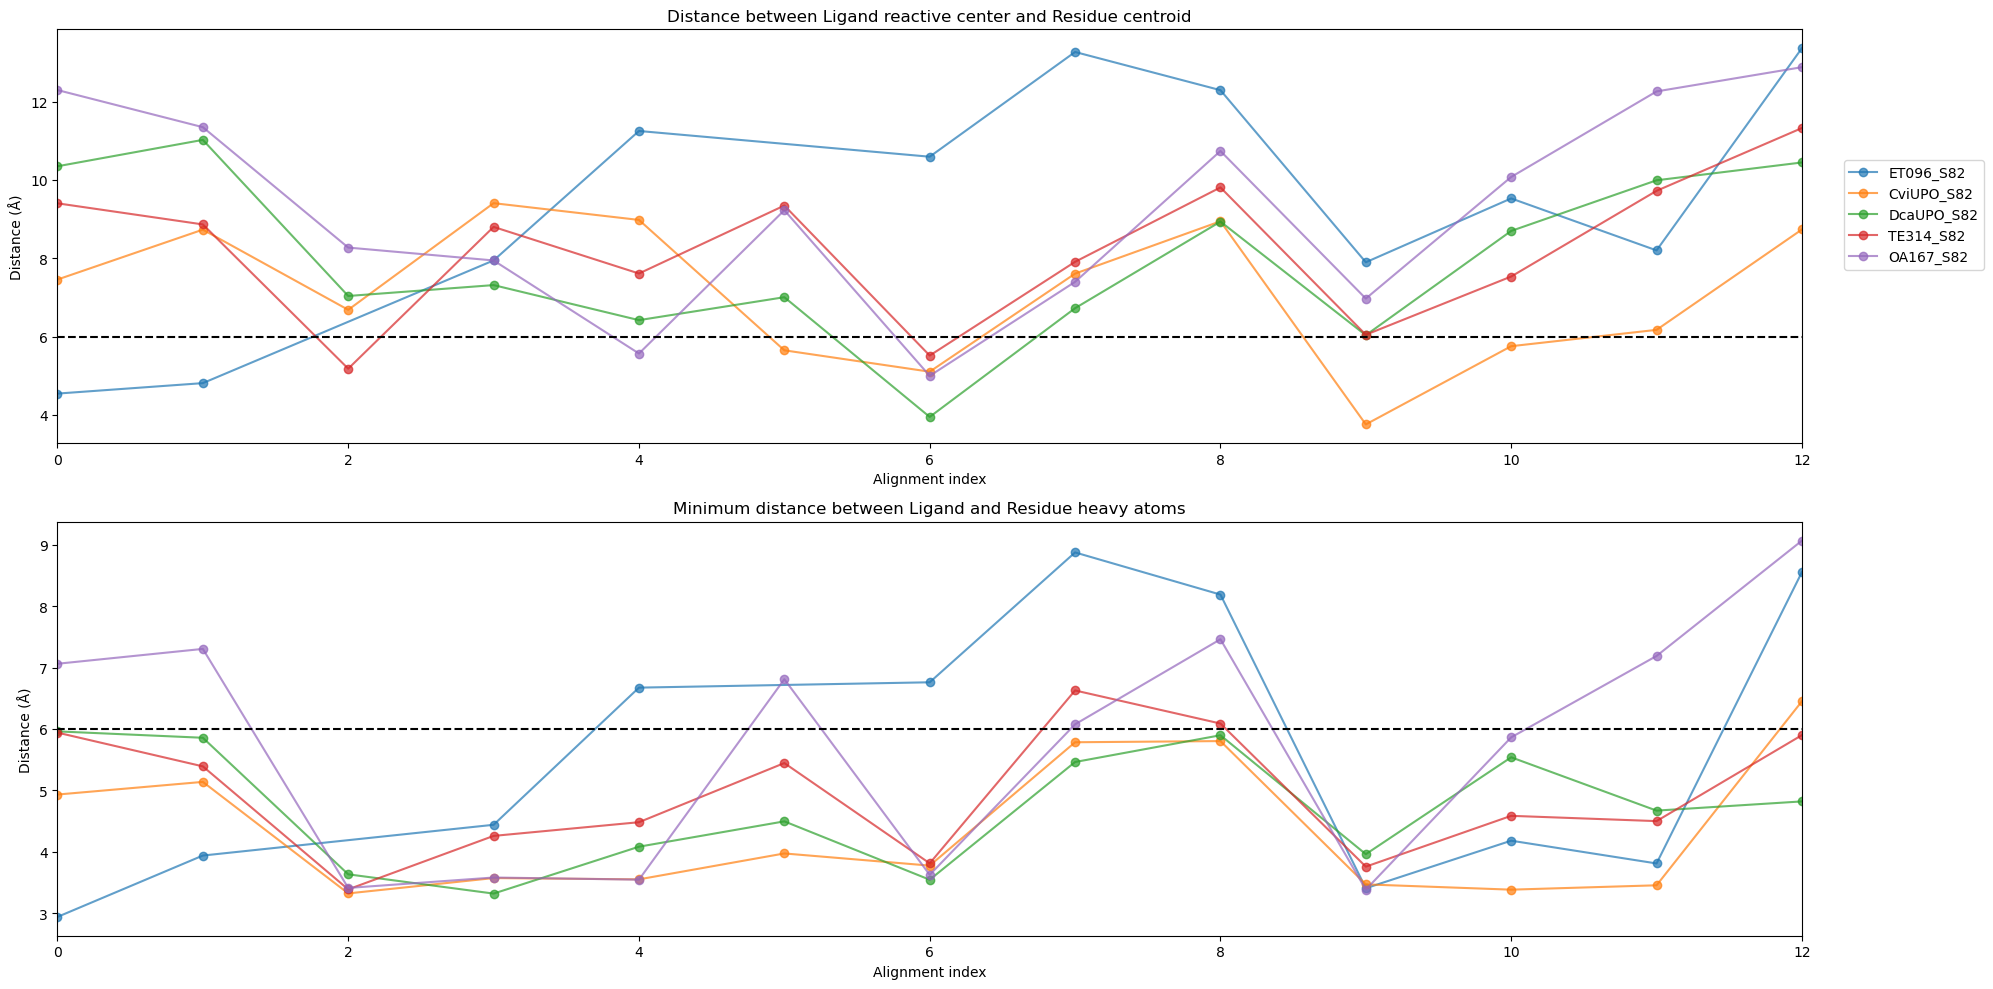

Saved all aligned proteins to YASARA scene: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/sce/UPO_peroxygenation_ali.sce
Saved ET096 to YASARA scene.
Saved CviUPO to YASARA scene.
Saved DcaUPO to YASARA scene.
Saved TE314 to YASARA scene.
Saved OA167 to YASARA scene.
Parsed 1933 atoms
Saved CSV to: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/structure_csv/ET096_S82.csv
[ET096_S82] Binding pocket residues  (38): [35, 36, 38, 60, 64, 70, 73, 74, 75, 76, 77, 78, 79, 80, 81, 83, 97, 102, 103, 104, 105, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 182, 218, 220, 223, 224, 227]
Centroid: [-9.88816071 -0.31677143 -0.64404643]
--- All Residue Atoms ---
Mean distance to binding pocket centroid: 10.2471
Mean MIN distance to binding pocket centroid: 8.57
--- Backbone Only ---
Mean distance to binding pocket centroid: 10.0673
Mean MIN distance to binding pocket centroid: None

Parsed 1883 atoms
Saved CSV to: /Users/charmainechia/D

In [4]:
result = run_binding_pocket_property_extraction(user_inputs)
print("status:", result.get("status", ""))
print("ligand_present:", result.get("ligand_present", ""))
print("combined_analysis_path:", result.get("combined_analysis_path", ""))


In [ ]:
summary = {
    "data_root": result.get("data_root", ""),
    "pdb_dir": result.get("pdb_dir", ""),
    "msa_dir": result.get("msa_dir", ""),
    "sce_dir": result.get("sce_dir", ""),
    "struct_csv_dir": result.get("struct_csv_dir", ""),
    "combined_analysis_path": result.get("combined_analysis_path", ""),
    "ligand_analysis_path": result.get("ligand_analysis_path", ""),
    "distal_analysis_path": result.get("distal_analysis_path", ""),
    "proximal_analysis_path": result.get("proximal_analysis_path", ""),
}
pd.Series(summary)


## Preview Combined Analysis
